In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
words = open('data/name.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [5]:
chars = sorted(set(''.join(words)))
stoi = {c: i+1 for i,c in enumerate(chars)}
stoi['.'] = 0
itos = {i: c for c, i in stoi.items()}

In [102]:
block_size = 5
X, Y = [], []
for word in words:
    context = [0] * block_size
    for c in word + '.':
        X.append(context)
        ix = stoi[c]
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [128]:
number_embeddings = 10
hidden_layer_neurons = 200
vocab_size = 27

generator = torch.Generator().manual_seed(2147483647)
embedding_table = torch.randn((vocab_size, number_embeddings), generator=generator)
weights_1 = torch.randn((number_embeddings * block_size, hidden_layer_neurons), generator=generator) * (5 / 3) / ((number_embeddings * block_size) ** 0.5)
weights_2 = torch.randn((hidden_layer_neurons, vocab_size), generator=generator) * 0.01
bias_2 = torch.randn(vocab_size) * 0

batch_norm_gains = torch.ones((1, hidden_layer_neurons))
batch_norm_bias = torch.ones((1, hidden_layer_neurons))

paramerter = [embedding_table, weights_1, weights_2, bias_2, batch_norm_gains, batch_norm_bias]
for p in paramerter:
    p.requires_grad = True

In [129]:
batch_size = 64
maximum_iterations = 20000

losses = []
for i in range(maximum_iterations):
    learning_rate = 0.1 if i < maximum_iterations * 0.8 else 0.01
    ix = torch.randint(0, X.shape[0], (batch_size,))
    embedded = embedding_table[X[ix]]
    linear_combination = embedded.view(-1, number_embeddings * block_size) @ weights_1

    # batch normalization
    mean = linear_combination.mean(0, keepdim=True)
    std = linear_combination.std(0, keepdim=True)
    linear_combination = batch_norm_gains * (linear_combination - mean) / std + batch_norm_bias

    hidden_layer = torch.tanh(linear_combination)
    logits = hidden_layer @ weights_2 + bias_2
    loss = F.cross_entropy(logits, Y[ix])
    losses.append(loss.log10().item())
    if i % 1000 == 0:
        print(f'loss={loss.item()}')

    for p in paramerter:
        p.grad = None

    loss.backward()

    for p in paramerter:
        p.data += -learning_rate * p.grad

loss=3.317500114440918
loss=2.2436699867248535
loss=1.928348183631897
loss=2.488992929458618
loss=2.1775758266448975
loss=2.3382015228271484
loss=2.2159957885742188
loss=2.3696703910827637
loss=2.1074342727661133
loss=2.3251867294311523
loss=2.1439907550811768
loss=1.9790164232254028
loss=2.184459924697876
loss=2.1541666984558105
loss=1.8728830814361572
loss=2.1715221405029297
loss=2.4092867374420166
loss=2.0092642307281494
loss=1.990789532661438
loss=2.0963354110717773


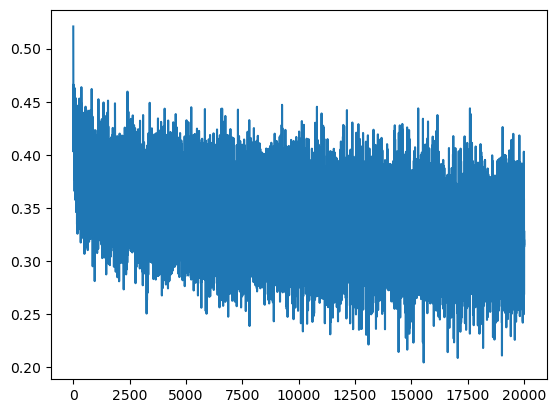

In [130]:
plt.plot(losses)

In [124]:
with torch.no_grad():
    emb = embedding_table[X]
    embeddings_concat = emb.view(emb.shape[0], -1)
    linear_combination = embeddings_concat @ weights_1
    batch_norm_mean = linear_combination.mean(dim=0, keepdim=True)
    batch_norm_std = linear_combination.std(dim=0, keepdim=True)

In [125]:
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = embedding_table[torch.tensor([context])]
        linear_combination = emb.view(emb.shape[0], -1) @ weights_1
        linear_combination = batch_norm_gains * (linear_combination - batch_norm_mean) / batch_norm_std + batch_norm_bias
        hidden_layer = torch.tanh(linear_combination)
        logits = hidden_layer @ weights_2 + bias_2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=generator).item()
        context  = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join([itos[i] for i in out]))



korolyn.
hetvia.
adrawie.
jalon.
helie.
nivaon.
jedian.
mavkesya.
kalopie.
jayzean.
kayla.
zicf.
nivik.
rayona.
kvien.
nylon.
azadelynt.
johki.
davi.
halre.
